In [2]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 51.4 MB/s eta 0:00:00


In [3]:
from ultralytics import YOLO
from google.colab import drive
import cv2
import matplotlib.pyplot as plt
import yaml
import torch

In [ ]:
drive.mount('/content/drive')
print("GPU Disponível:", torch.cuda.is_available())

GPU Disponível: True


In [5]:
!unzip -q "/content/drive/MyDrive/computer_vision_lab/person_dataset.zip" -d /content/person_dataset

In [6]:
caminho_yaml = "/content/person_dataset/data.yaml"

with open(caminho_yaml, 'r') as f :
    dados = yaml.safe_load(f)

dados['path'] = "/content/person_dataset"
dados['train'] = "train/images"
dados['val'] = "valid/images"

with open(caminho_yaml, 'w') as f:
    yaml.dump(dados, f)

In [ ]:
# importando modelo nano para começar o treinamento
model = YOLO('yolo26n.pt')

model.train(
    data=caminho_yaml,
    epochs=10,
    imgsz=640,
    device=0,
    batch=32,
    cache=True
)

Ultralytics 8.4.67 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/person_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100,

: 

: 

: 

In [ ]:
# path do modelo já treinado
caminho_modelo = '/content/runs/detect/train/weights/best.pt'
model = YOLO(caminho_modelo)

# rodando validação com batch menor e menos workers para evitar travamentos
metricas = model.val(
    data='/content/person_dataset/data.yaml',
    batch=16,
    workers=2,
    device=0
)

# métricas de validação
print("Precisão das Caixas (mAP50):", metricas.box.map50)
print("Precisão Rigorosa (mAP50-95):", metricas.box.map)

Modelo carregado com sucesso! Iniciando validação segura...
Ultralytics 8.4.67 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 27.2±20.6 MB/s, size: 57.8 KB)
val: Scanning /content/person_dataset/valid/labels.cache... 1071 images, 44 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1071/1071 172.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 67/67 5.9it/s 11.3s0.2s
                   all       1071       2293      0.804      0.713       0.79      0.515
Speed: 1.3ms preprocess, 3.7ms inference, 0.0ms loss, 0.2ms postprocess per image
Results saved to /content/runs/detect/val

--- RESULTADOS DA VALIDAÇÃO ---
Precisão das Caixas (mAP50): 0.7902024092494844
Precisão Rigorosa (mAP50-95): 0.5148900804963938



image 1/1 /content/drive/MyDrive/computer_vision_lab/nois.jpg: 640x384 1 Persona, 89.6ms
Speed: 3.2ms preprocess, 89.6ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 384)


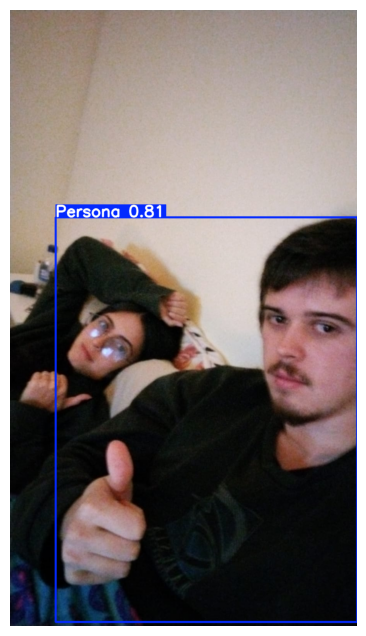

In [ ]:
# carregando modelo para teste
meu_modelo = YOLO('/content/runs/detect/train/weights/best.pt')

# caminho da imagem de teste
caminho_teste = '/content/drive/MyDrive/computer_vision_lab/imagem_teste.jpg'

# rodando teste
resultados = meu_modelo(caminho_teste)

# plotando foto anotada
foto_anotada = resultados[0].plot()
foto_rgb = cv2.cvtColor(foto_anotada, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 8))
plt.imshow(foto_rgb)
plt.axis('off')
plt.show()